In [1]:
import sapphire

In [9]:
from sapphire.utils import read_config
config = read_config.get({'path_config':'/mnt/ceph/users/vpandya/sapphire/scripts/config.yaml'})

### now modify for latin hypercube sampling
config['runtype'] = 'sampling'
config['rng_sample'] = 1 # can change this random seed

# we'll continue to use the same default bounds for uniform random sampling as we did for inference
config['sampling_config']

{'method': 'lhs',
 'Nsamples': 100,
 'params_bounds': {'A_M': [-2.0, 1.0],
  'alpha0_M': [-2.0, 0.0],
  'A_E': [-2.0, 0.0],
  'alpha0_E': [-2.0, 0.0],
  'A_SF': [0.0, 1.1],
  'alpha0_SF': [-2.0, 0.0],
  'A_Z': [-2.0, 0.0],
  'alpha0_Z': [-2.0, 0.0]}}

In [10]:
out_sapphire = sapphire.run(config)
sol = out_sapphire[0]

reading /mnt/ceph/users/vpandya/sapphire/scripts/config.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 1,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 3,
                            'adam_logL': 'numpyro',
                            'engine': 'nuts',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 2000,
                            'num_warmup': 2000,
                            'random_mock': True,
                            'write_output': True},
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_err_fgas': 0.0,
    'obs_err_mzr': 0.0,
    'obs_err_smhm': 0.0,
    'obs_name': 'lit',
    'output_path': '/mnt/ceph/users/vpandya/sapphire_outputs/',
    'output_prefix': 'numpyro_{obs_name}_chain{chain_num}',
    'output_suffix': '{flag_smhm}{f

In [1]:
### read obs_stats to get x0 and bw for NW regression
# WARNING: sapphire needs to be refactored since loading this first screws up num_cpus for XLA 
from sapphire.utils import read_obs
obs_manga = read_obs.read_manga({'data_path':'/mnt/ceph/users/vpandya/sapphire/data/','obs_name':'manga'})
obs_lit = read_obs.read_lit({'data_path':'/mnt/ceph/users/vpandya/sapphire/data/','obs_name':'manga'}) # behroozi SMHM
obs_mix = read_obs.read_mix({'data_path':'/mnt/ceph/users/vpandya/sapphire/data/','obs_name':'mix'}) # behroozi SMHM

In [8]:
### do nadaraya-watson regression
import jax
from sapphire.summaries import gaussian_kernel_regression as gkr

# we will vmap over the summarize_mock function so all 100 solutions get summarized at once
prior_gkrs = jax.vmap(gkr.summarize_mock,in_axes=(0,None))(sol,obs_mix)

# following return signature of summarize_mock
(mock_x0_smhm, mock_bw_smhm, mock_avg_smhm, mock_err_smhm,
 mock_x0_fgas, mock_bw_fgas, mock_avg_fgas, mock_err_fgas,
 mock_x0_mzr, mock_bw_mzr, mock_avg_mzr, mock_err_mzr) = prior_gkrs

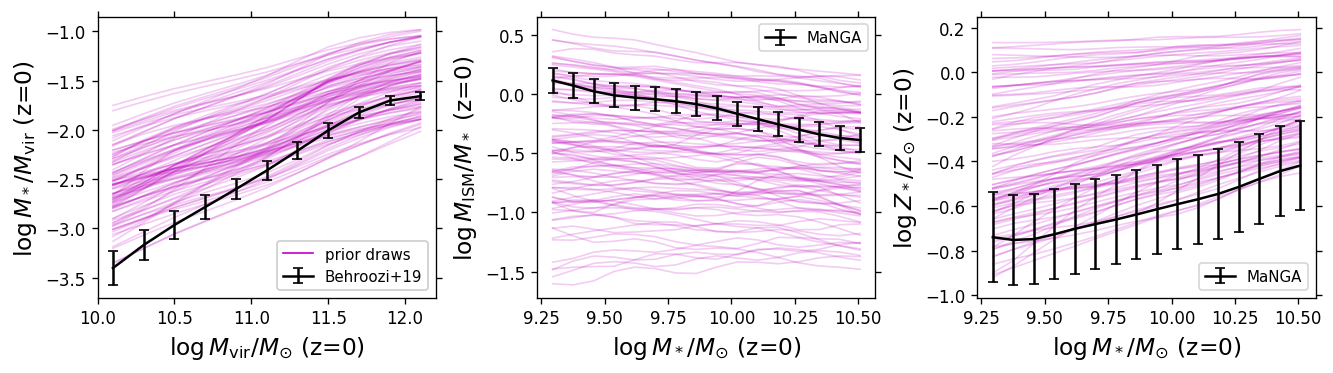

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

color_obs = 'k'
color_prior = 'm'

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),constrained_layout=True)
ax_smhm, ax_fgas, ax_mzr = axes

##### first the data/constraints
ax_smhm.errorbar(obs_mix[0],obs_mix[2],yerr=obs_mix[3],
             fmt='-',color=color_obs,capsize=3,zorder=np.inf,label='Behroozi+19')

# axes[0].set_xscale('log')
ax_smhm.set_xlabel(r'$\log M_{\rm vir}/M_{\odot}$ (z=0)',fontsize=14)
ax_smhm.set_ylabel(r'$\log M_*/M_{\rm vir}$ (z=0)',fontsize=14)

ax_fgas.errorbar(obs_mix[4],obs_mix[6],yerr=obs_mix[7],
                 fmt='-',capsize=3,zorder=np.inf,color=color_obs,label='MaNGA')

# plt.xscale('log')
ax_fgas.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_fgas.set_ylabel(r'$\log M_{\rm ISM}/M_*$ (z=0)',fontsize=14)

ax_mzr.errorbar(obs_mix[8],obs_mix[10],yerr=obs_mix[11],
                 fmt='-',capsize=3,zorder=np.inf,color=color_obs,label='MaNGA')

ax_mzr.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_mzr.set_ylabel(r'$\log Z_*/Z_{\odot}$ (z=0)',fontsize=14)

##### plot random draws from posterior

for inum,ival in enumerate(range(mock_x0_smhm.shape[0])):
    
    ax_smhm.plot(mock_x0_smhm[ival],mock_avg_smhm[ival],'-',color=color_prior,alpha=0.2,lw=1,
                label=r'prior draws' if inum==0 else '__none__')

    ax_fgas.plot(mock_x0_fgas[ival],mock_avg_fgas[ival],'-',color=color_prior,alpha=0.2,lw=1,)

    ax_mzr.plot(mock_x0_mzr[ival],mock_avg_mzr[ival],'-',color=color_prior,alpha=0.2,lw=1)


# orig_xlim, orig_ylim = ax_smhm.get_xlim(), ax_smhm.get_ylim() 
# ax_smhm.errorbar(obs_lit[0],obs_lit[2],yerr=obs_lit[3],fmt='-',color='c',capsize=3,zorder=np.inf,label='Behroozi+19',alpha=0.9)
# ax_smhm.set_xlim(orig_xlim)
# ax_smhm.set_ylim(orig_ylim)


leg = ax_smhm.legend(fontsize=9,fancybox=True,framealpha=1,ncol=1,loc='lower right')
leg.get_lines()[0].set_alpha(1.0)

ax_fgas.legend(fontsize=9)
ax_mzr.legend(fontsize=9)

# plt.savefig('figures/prior_predictive_checks_mix.png',bbox_inches='tight',dpi=300,facecolor='w')